In [1]:
module OddParity
    using DifferentialEquations

    T = Float64
    gc2 = T(7.42365e-29)
    G = T(6.6732e-8)
    cc = T(2.9979e10)
    Msun = T(1.47664)
    μ0 = T(1e-6)
    μsurf = T(1e-12)

    # --------------------------------------------------------------------------
    # Equation of State
    # --------------------------------------------------------------------------
    function ρ_eos(p1::T) where {T}
        K = T(100) * Msun^2
        γ0 = T(2)
        ρb = (p1 / K)^(T(1)/γ0)
        return ρb + p1
    end

    # --------------------------------------------------------------------------
    # Background (TOV) Solution exactly mirroring even-parity framework
    # --------------------------------------------------------------------------
    function tov_derivatives!(du, u, p_params, x)
        r_var, m_var, νb_var = u
        p_val = exp(x)
        ρ_val = ρ_eos(p_val)
        dmdr = 4 * T(pi) * r_var^2 * ρ_val
        dνdr = 2 * (m_var + 4 * T(pi) * r_var^3 * p_val) / (r_var * (r_var - 2 * m_var))
        dpdr = -(ρ_val + p_val) / 2 * dνdr
        drdx = p_val / dpdr
        du[1] = drdx; du[2] = drdx * dmdr; du[3] = drdx * dνdr
    end

    function solve_tov(p0_val::T)
        h1 = μ0 * p0_val
        x0 = log(p0_val - h1)
        ρ0 = ρ_eos(p0_val)
        r0 = sqrt(2 * h1 / (4 * T(pi) * (ρ0 + p0_val) * (ρ0/3 + p0_val)))
        m0 = (4 * T(pi) / 3) * ρ0 * r0^3
        νb0 = T(0)
        xf = log(μsurf * p0_val)
        prob = ODEProblem(tov_derivatives!, [r0, m0, νb0], (x0, xf))
        tol = 1e-10
        sol = solve(prob, Tsit5(), reltol=tol, abstol=tol)
        r_f, m_f, νb_f = sol.u[end]
        ν0 = -νb_f + log(1 - 2 * m_f / r_f)
        return (; sol, x0, xf, M_tov=m_f, R_tov=r_f, ν0)
    end

    function target_compactness_func(p0_val::T, target_C::T)
        tov = solve_tov(p0_val)
        return (tov.M_tov / tov.R_tov) - target_C
    end

    function find_p0_for_compactness(target_C::T, p0_guess1::T, p0_guess2::T; tol::T=T(1e-8), max_iter::Int=50)
        p0_0 = p0_guess1
        p0_1 = p0_guess2
        f0 = target_compactness_func(p0_0, target_C)
        f1 = target_compactness_func(p0_1, target_C)
        for i in 1:max_iter
            if abs(f1) < tol return p0_1 end
            p0_new = p0_1 - f1 * (p0_1 - p0_0) / (f1 - f0)
            
            # Prevent unphysical negative pressure from secant method mathematically overshooting!
            if p0_new <= 0.0
                p0_new = p0_1 / 2.0
            end
            
            p0_0 = p0_1; f0 = f1; p0_1 = p0_new
            f1 = target_compactness_func(p0_1, target_C)
        end
        error("Secant method failed to converge for target compactness $target_C. Target likely exceeds the EOS theoretical maximum compactness.")
    end

    # --------------------------------------------------------------------------
    # Odd-Parity Perturbation
    # --------------------------------------------------------------------------
    function odd_derivatives!(du, u, p_params, x)
        tov_sol, l, omega, ν0_offset = p_params
        h, hp = u
        
        # Evaluate background geometry
        r, m, νb = tov_sol(x)
        ν = νb + ν0_offset
        p0 = exp(x)
        eps = ρ_eos(p0)
        
        # Geometry shortcuts
        exp_lam = 1.0 / (1.0 - 2.0 * m / r)
        exp_nu = exp(ν)
        exp_2nu = exp_nu * exp_nu
        exp_lam_nu = exp_lam * exp_nu
        exp_lam_minus_nu = exp_lam / exp_nu
        
        # Powers (chained to avoid allocation/power overhead)
        r2 = r * r
        om2 = omega * omega
        om2_r2 = om2 * r2
        om4_r4 = om2_r2 * om2_r2
        
        # Background derivatives
        nu_p = 2.0 * (m + 4.0 * T(pi) * r * r2 * p0) / (r * (r - 2.0 * m))
        p_prime = -(eps + p0) / 2.0 * nu_p
        drdx = p0 / p_prime
        
        # Exact paper components for Odd-Parity eq (53)
        Λl = T(l^2 + l - 2)
        D = Λl * exp_nu - om2_r2
        
        A_num = 4.0 * T(pi) * Λl * r * exp_lam_nu * (eps + p0) - 
                r * om2 * (exp_lam * (4.0 * T(pi) * r2 * (eps - p0) - 1.0) + 3.0)
                
        B_num = (1.0 / r2) * (
                    2.0 * (Λl * exp_nu + 2.0 * om2_r2) + 
                    exp_lam_minus_nu * (
                        Λl * exp_2nu * (Λl - 8.0 * T(pi) * r2 * (eps + p0)) - 
                        2.0 * om2_r2 * exp_nu * (Λl + 1.0 - 4.0 * T(pi) * r2 * (eps - p0)) + 
                        om4_r4
                    )
                )

        # ----------------------------------------------------------------------
        # OUT-OF-EQUILIBRIUM (OoE) PLACEHOLDERS
        # ----------------------------------------------------------------------
        # When fully tracking OoE effects, h(r) couples with h1(r) and U(r).
        # We set these to zero for now. Note: once activated, the ODE integration 
        # MUST migrate to complex variables since S_Source involves 'im * omega'.
        S_1A  = 0.0
        S_1Ap = 0.0
        S_Z   = 0.0
        
        # Evaluated Source terms spanning Eq 53 from the provided analytical draft:
        # S_source = (16.0*T(pi)*exp_nu / (im*omega*r)) * (Λl*exp_nu + exp_lam*(Λl*exp_nu*(1.0 - 4.0*T(pi)*r2*(eps - p0)) - 2.0*om2_r2*(1.0 - 2.0*T(pi)*r2*(eps - 3.0*p0))) + 2.0*om2_r2) * S_1A + 
        #            (16.0*T(pi)*exp_nu / (im*omega)) * D * S_1Ap - 
        #            (8.0*T(pi)*exp_lam / (im*omega*r2)) * D * S_Z
        S_source = 0.0
                
        h_double_prime = (A_num / D) * hp + (B_num / D) * h + (S_source / D)
        
        # Integrate with respect to x
        du[1] = drdx * hp
        du[2] = drdx * h_double_prime
    end

    function solve_odd(p0_val::T, l::Int, omega::Number)
        tov = solve_tov(p0_val)
        x0, xf, sol = tov.x0, tov.xf, tov.sol
        r0 = sol(x0)[1]
        
        # ----------------------------------------------------------------------
        # High Accuracy Frobenius Expansion Initial Conditions at r -> 0
        # ----------------------------------------------------------------------
        # The regular solution follows: h(r) = r^(l+1) + c2 * r^(l+3) + ...
        # Evaluating components accurately up to O(r^2):
        
        pc   = p0_val
        eps0 = ρ_eos(pc)
        exp_nuc = exp(tov.ν0)
        
        # Metric second derivatives terms: e^λ ≈ 1 + λ2*r^2; e^ν ≈ e^νc(1 + ν2*r^2)
        λ2 = 8.0 * T(pi) / 3.0 * eps0
        ν2 = 4.0 * T(pi) / 3.0 * (eps0 + 3.0 * pc)
        Λl = T(l^2 + l - 2)
        
        # Extracted limiting coefficients exactly derived from ODE limit balance:
        D0 = Λl * exp_nuc
        D2 = Λl * exp_nuc * ν2 - omega^2
        A1 = 4.0 * T(pi) * Λl * exp_nuc * (eps0 + pc) - 2.0 * omega^2
        B2 = exp_nuc * Λl * (ν2 * (2.0 + Λl) + Λl * λ2 - 8.0 * T(pi) * (eps0 + pc)) + 2.0 * omega^2 * (1.0 - Λl)
        
        # Solve for exact continuous c2 error term
        c2 = (A1 * (l + 1.0) + B2 - D2 * l * (l + 1.0)) / (2.0 * (2.0 * l + 3.0) * D0)
        
        # Set normalized Initial Value (H0=1)
        h0  = r0^(l + 1) * (1.0 + c2 * r0^2)
        hp0 = (l + 1) * r0^l + c2 * (l + 3) * r0^(l + 2)
        
        prob = ODEProblem(odd_derivatives!, [h0, hp0], (x0, xf), (sol, l, omega, tov.ν0))
        odd_sol = solve(prob, Tsit5(), reltol=1e-10, abstol=1e-10)
        
        return (; sol=odd_sol, tov)
    end

    function eval_h_ratio(p0_val::T, l::Int, omega::Number)
        res = solve_odd(p0_val, l, omega)
        h_R, hp_R = res.sol.u[end]
        return hp_R / h_R
    end

    function eval_zeta(p0_val::T, l::Int, omega::Number)
        res = solve_odd(p0_val, l, omega)
        h_R, hp_R = res.sol.u[end]
        R = res.tov.R_tov
        M = res.tov.M_tov
        
        # Evaluate constants at R
        e_nu = 1.0 - 2.0 * M / R
        e_lam = 1.0 / e_nu
        Λl = T(l^2 + l - 2)
        
        om2 = omega^2
        R2 = R^2
        
        """        # RW Denominator mapping and its derivative
        D_R = Λl * e_nu - om2 * R2
        D_prime_R = 2.0 * M * Λl / R2 - 2.0 * om2 * R
        
        # Second derivative h''(R) using exterior vacuum Eq 53 exactly (ε=p=0 at boundary)
        A_surf = (R * om2 * (e_lam - 3.0)) / D_R
        B_surf = (2.0 * (Λl * e_nu + 2.0 * om2 * R2) + 
                  e_lam^2 * (Λl^2 * e_nu^2 - 2.0 * om2 * R2 * e_nu * (Λl + 1.0) + om2^2 * R2^2)) / (R2 * D_R)
        
        hpp_R = A_surf * hp_R + B_surf * h_R
        
        # Zeta Factor: Z_RW = f(r) * g(r) => (Z'/Z) = f'/f + g'/g
        # The complex amplitude matches cancel completely from the ratio!
        nu_prime_R = 2.0 * M / (R^2 * e_nu)
        f_ratio = 1.0 / R + nu_prime_R - D_prime_R / D_R
        
        g_R = hp_R - 2.0 * h_R / R
        g_prime_R = hpp_R - 2.0 * hp_R / R + 2.0 * h_R / R2
        g_ratio = g_prime_R / g_R"""
                # --- 2. Construct Z'/Z at r = R (existing logic) ---
        e_nu = 1.0 - 2.0 * M / R
        e_lam = 1.0 / e_nu
        Λl = Float64(l^2 + l - 2)
        om2 = omega^2
        R2_sq = R^2

        D_R = Λl * e_nu - om2 * R2_sq
        D_prime_R = 2.0 * M * Λl / R2_sq - 2.0 * om2 * R

        A_surf = (R * om2 * (e_lam - 3.0)) / D_R
        B_surf = (2.0 * (Λl * e_nu + 2.0 * om2 * R2_sq) + 
                e_lam^2 * (Λl^2 * e_nu^2 - 2.0 * om2 * R2_sq * e_nu * (Λl + 1.0) + om2^2 * R2_sq^2)) / (R2_sq * D_R)

        hpp_R = A_surf * hp_R + B_surf * h_R

        nu_prime_R = 2.0 * M / (R^2 * e_nu)

        f_ratio = 1.0 / R + nu_prime_R - D_prime_R / D_R

        g_R = 2h_R - R * hp_R
        g_prime_R = hp_R - R * hpp_R
        g_ratio = g_prime_R / g_R
        ν_prime_R = 2M / (R^2 * (1 - 2M/R))
        λ_prime_R = -ν_prime_R / (1 - 2M/R)   

        term1 = 0.5 * (-λ_prime_R + ν_prime_R)

        term2 = (2R*om2 - e_nu * Λl * ν_prime_R) / (e_nu * Λl - R^2 * om2)

        Z_ratio_R = term1 + term2 + g_ratio

        zeta = 2.0 * M * Z_ratio_R
        
        return zeta
    end

    function eval_response_BA(p0_val::T, l::Int, omega::Number)
        res = solve_odd(p0_val, l, omega)
        h_R, hp_R = res.sol.u[end]
        R = res.tov.R_tov
        M = res.tov.M_tov
        
        # Evaluate constants at R
        e_nu = 1.0 - 2.0 * M / R
        e_lam = 1.0 / e_nu
        Λl = T(l^2 + l - 2)
        
        om2 = omega^2
        R2 = R^2
        
        # RW Denominator mapping and its derivative
        D_R = Λl * e_nu - om2 * R2
        D_prime_R = 2.0 * M * Λl / R2 - 2.0 * om2 * R
        
        # Second derivative h''(R) using exterior vacuum Eq 53 exactly (ε=p=0 at boundary)
        A_surf = (R * om2 * (e_lam - 3.0)) / D_R
        B_surf = (2.0 * (Λl * e_nu + 2.0 * om2 * R2) + 
                  e_lam^2 * (Λl^2 * e_nu^2 - 2.0 * om2 * R2 * e_nu * (Λl + 1.0) + om2^2 * R2^2)) / (R2 * D_R)
        
        hpp_R = A_surf * hp_R + B_surf * h_R
        
        # Zeta Factor: Z_RW = f(r) * g(r) => (Z'/Z) = f'/f + g'/g
        nu_prime_R = 2.0 * M / (R^2 * e_nu)
        f_ratio = 1.0 / R + nu_prime_R - D_prime_R / D_R
        
        g_R = hp_R - 2.0 * h_R / R
        g_prime_R = hpp_R - 2.0 * hp_R / R + 2.0 * h_R / R2
        g_ratio = g_prime_R / g_R
        
        Z_ratio = f_ratio + g_ratio
        
        # B/A response
        BA = R^5 * (3.0 - R * Z_ratio) / (R * Z_ratio + 2.0)
        return BA
    end
end


using .OddParity

T = Float64
l = 2
omega = T(0.004)
target_C = T(0.14)

println("--- Starting Odd Parity Verification ---")
println("Finding p0 for Target Compactness C = ", target_C)
p0_c14 = OddParity.find_p0_for_compactness(target_C, T(1e-5), T(1e-4))
println("p0_c14 = ", p0_c14)

println("\nIntegrating Odd Parity ODE to the surface (l=", l, ", omega=", omega, ")...")
try
    res = OddParity.solve_odd(p0_c14, l, omega)
    u_surf = res.sol.u[end]
    println("Integration Successful!")
    println("Surface values at R = ", res.tov.R_tov, " :")
    println("  h(R)  = ", u_surf[1])
    println("  h'(R) = ", u_surf[2])
    
    zeta_odd = OddParity.eval_zeta(p0_c14, l, omega)
    println("Odd Parity Zeta = ", zeta_odd)
catch e
    println("Error evaluating odd parity integration! ", e)
    rethrow(e)
end

--- Starting Odd Parity Verification ---
Finding p0 for Target Compactness C = 0.14
p0_c14 = 6.4643698065927e-5

Integrating Odd Parity ODE to the surface (l=2, omega=0.004)...
Integration Successful!
Surface values at R = 14.369082624566907 :
  h(R)  = 4045.596680843791
  h'(R) = 941.552088110722
Odd Parity Zeta = 0.897090117988138


    function eval_zeta(p0_val::T, l::Int, omega::T)
        res = solve_odd(p0_val, l, omega)
        h_R, hp_R = res.sol.u[end]
        R = res.tov.R_tov
        M = res.tov.M_tov
        
        # Evaluate constants at R
        e_nu = 1.0 - 2.0 * M / R
        e_lam = 1.0 / e_nu
        Λl = T(l^2 + l - 2)
        
        om2 = omega^2
        R2 = R^2
        
        # RW Denominator mapping and its derivative
        D_R = Λl * e_nu - om2 * R2
        D_prime_R = 2.0 * M * Λl / R2 - 2.0 * om2 * R
        
        # Second derivative h''(R) using exterior vacuum Eq 53 exactly (ε=p=0 at boundary)
        A_surf = (R * om2 * (e_lam - 3.0)) / D_R
        B_surf = (2.0 * (Λl * e_nu + 2.0 * om2 * R2) + 
                  e_lam^2 * (Λl^2 * e_nu^2 - 2.0 * om2 * R2 * e_nu * (Λl + 1.0) + om2^2 * R2^2)) / (R2 * D_R)
        
        hpp_R = A_surf * hp_R + B_surf * h_R
        
        # Zeta Factor: Z_RW = f(r) * g(r) => (Z'/Z) = f'/f + g'/g
        # The complex amplitude matches cancel completely from the ratio!
        f_ratio = 1.0 / R - D_prime_R / D_R
        
        g_R = hp_R - 2.0 * h_R / R
        g_prime_R = hpp_R - 2.0 * hp_R / R + 2.0 * h_R / R2
        g_ratio = g_prime_R / g_R
        
        zeta = 2.0 * M * (f_ratio + g_ratio)
        
        return zeta
    end

In [8]:
941.552088110722/4045.596680843791

0.23273503574121537

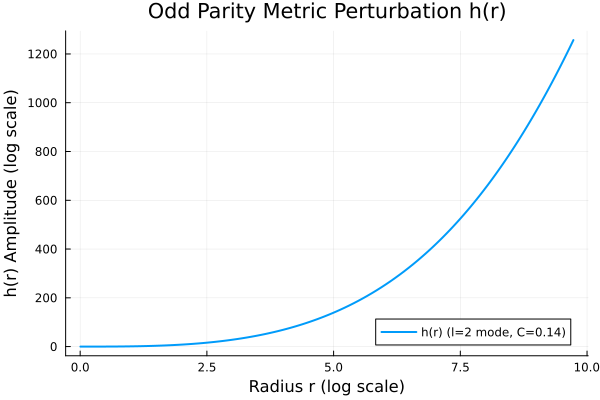

In [25]:
#include("odd_parity.jl")
using Plots
using .OddParity

T = Float64
l = 2
omega = T(0.004)
target_C = T(0.14)

p0 = OddParity.find_p0_for_compactness(target_C, T(1e-5), T(1e-4))
res = OddParity.solve_odd(p0, l, omega)

sol = res.sol
r_vals = Float64[]
h_vals = Float64[]

for x in sol.t
    u = sol(x)
    r = res.tov.sol(x)[1]
    push!(r_vals, r)
    push!(h_vals, u[1])
end

p = plot(r_vals, h_vals,
    title="Odd Parity Metric Perturbation h(r)",
    xlabel="Radius r (log scale)",
    ylabel="h(r) Amplitude (log scale)",
    linewidth=2, label="h(r) (l=2 mode, C=0.14)", legend=:bottomright)
    
#savefig(p, "odd_parity_plot.png")
#println("Plot saved to odd_parity_plot.png")


In [ ]:
#include("odd_parity.jl")
using .OddParity
using Plots
using DelimitedFiles

T = Float64
l = 2
om_M_vals = [1e-3, 1e-2, 1e-1]

# Generating 30 density steps spanning from your limits
C_vals = range(T(0.05), T(0.25), length=30)

results = []
push!(results, ["Compactness", "omega_M", "omega", "M_tov", "Zeta_Odd"])

plot_dict = Dict(om => Float64[] for om in om_M_vals)
C_plot = Float64[]

for C in C_vals
    println("Processing Compactness C = ", C)
    
    p0 = 0.0
    M = 0.0
    try
        p0 = OddParity.find_p0_for_compactness(T(C), T(1e-6), T(1e-4))
        
        if p0 <= 0
            throw(DomainError(p0, "Negative p0 found from secant overshoot!"))
        end
        
        tov = OddParity.solve_tov(p0)
        M = tov.M_tov
        push!(C_plot, C)
        
        for om_M in om_M_vals
            omega = om_M / M
            zeta = OddParity.eval_zeta(p0, l, omega)
            push!(results, [C, om_M, omega, M, zeta])
            push!(plot_dict[om_M], zeta)
        end
    catch e
        println("Skipping C = ", C, " due to error: ", e)
    end
end

open("odd_parity_zeta.csv", "w") do io
    writedlm(io, results, ',')
end
println("Saved dataset successfully to odd_parity_zeta.csv")

p = plot(title="Odd Parity Zeta vs Compactness (l=2)", 
         xlabel="Compactness (M/R)", 
         ylabel="Zeta_Odd", 
         legend=:topleft)

for om_M in om_M_vals
    plot!(p, C_plot, plot_dict[om_M], label="omega*M = $om_M", linewidth=2, marker=:circle, markersize=3)
end

savefig(p, "odd_parity_zeta_plot_new.png")
println("Saved plot sequence successfully to odd_parity_zeta_plot_new.png")


Processing Compactness C = 0.05
Processing Compactness C = 0.056896551724137934
Processing Compactness C = 0.06379310344827586
Processing Compactness C = 0.0706896551724138
Processing Compactness C = 0.07758620689655173
Processing Compactness C = 0.08448275862068966
Processing Compactness C = 0.09137931034482759
Processing Compactness C = 0.09827586206896552
Processing Compactness C = 0.10517241379310345
Processing Compactness C = 0.11206896551724138
Processing Compactness C = 0.11896551724137931
Processing Compactness C = 0.12586206896551724
Processing Compactness C = 0.13275862068965516
Processing Compactness C = 0.1396551724137931
Processing Compactness C = 0.14655172413793102
Processing Compactness C = 0.15344827586206897
Processing Compactness C = 0.16034482758620688
Processing Compactness C = 0.16724137931034483
Processing Compactness C = 0.17413793103448275
Processing Compactness C = 0.1810344827586207
Processing Compactness C = 0.1879310344827586
Processing Compactness C = 0.19

In [7]:
#include("odd_parity.jl")
using .OddParity
using Plots
using DelimitedFiles

T = Float64
l = 2
om_M_vals = [1e-3, 1e-2, 1e-1]
C_vals = range(T(0.05), T(0.25), length=30)

results = []
push!(results, ["Compactness", "omega_M", "omega", "M_tov", "h_ratio_Odd"])

plot_dict = Dict(om => Float64[] for om in om_M_vals)
C_plot = Float64[]

for C in C_vals
    println("Processing C = ", C)
    
    p0 = 0.0
    M = 0.0
    try
        p0 = OddParity.find_p0_for_compactness(T(C), T(1e-6), T(1e-4))
        if p0 <= 0
            throw(DomainError(p0, "Negative p0 found"))
        end
        tov = OddParity.solve_tov(p0)
        M = tov.M_tov
        
        push!(C_plot, C)
        
        for om_M in om_M_vals
            omega = om_M / M
            h_ratio = OddParity.eval_h_ratio(p0, l, omega)
            push!(results, [C, om_M, omega, M, h_ratio])
            push!(plot_dict[om_M], h_ratio)
        end
    catch e
        println("Skipping C = ", C, " due to error: ", e)
    end
end

open("odd_parity_hratio.csv", "w") do io
    writedlm(io, results, ',')
end
println("Saved dataset to odd_parity_hratio.csv")

p = plot(title="Odd Parity h'/h vs Compactness (l=2)", 
         xlabel="Compactness (M/R)", 
         ylabel="h_ratio", 
         legend=:topleft)

for om_M in om_M_vals
    plot!(p, C_plot, plot_dict[om_M], label="omega*M = $om_M", linewidth=2, marker=:circle, markersize=3)
end

savefig(p, "odd_parity_hratio_plot.png")
println("Saved plot to odd_parity_hratio_plot.png")


Processing C = 0.05
Processing C = 0.056896551724137934
Processing C = 0.06379310344827586
Processing C = 0.0706896551724138
Processing C = 0.07758620689655173
Processing C = 0.08448275862068966
Processing C = 0.09137931034482759
Processing C = 0.09827586206896552
Processing C = 0.10517241379310345
Processing C = 0.11206896551724138
Processing C = 0.11896551724137931
Processing C = 0.12586206896551724
Processing C = 0.13275862068965516
Processing C = 0.1396551724137931
Processing C = 0.14655172413793102
Processing C = 0.15344827586206897
Processing C = 0.16034482758620688
Processing C = 0.16724137931034483
Processing C = 0.17413793103448275
Processing C = 0.1810344827586207
Processing C = 0.1879310344827586
Processing C = 0.19482758620689655
Processing C = 0.20172413793103447
Processing C = 0.20862068965517241
Processing C = 0.21551724137931033
Processing C = 0.22241379310344828
Processing C = 0.2293103448275862
Processing C = 0.23620689655172414
Processing C = 0.24310344827586206
Proc

In [37]:
#include("odd_parity.jl")

module QNMFinder
    using LinearAlgebra
    using ..OddParity
    using DifferentialEquations
    function eval_k(p0_val::Float64, l::Int, omega::Number; R2_factor=1.2)

        # --- 1. Solve interior ---
        res = OddParity.solve_odd(p0_val, l, omega)
        h_R, hp_R = res.sol.u[end]

        R = res.tov.R_tov
        M = res.tov.M_tov

        # --- 2. Construct Z'/Z at r = R (existing logic) ---
        e_nu = 1.0 - 2.0 * M / R
        e_lam = 1.0 / e_nu
        Λl = Float64(l^2 + l - 2)
        om2 = omega^2
        R2_sq = R^2

        D_R = Λl * e_nu - om2 * R2_sq
        D_prime_R = 2.0 * M * Λl / R2_sq - 2.0 * om2 * R

        A_surf = (R * om2 * (e_lam - 3.0)) / D_R
        B_surf = (2.0 * (Λl * e_nu + 2.0 * om2 * R2_sq) + 
                e_lam^2 * (Λl^2 * e_nu^2 - 2.0 * om2 * R2_sq * e_nu * (Λl + 1.0) + om2^2 * R2_sq^2)) / (R2_sq * D_R)

        hpp_R = A_surf * hp_R + B_surf * h_R

        nu_prime_R = 2.0 * M / (R^2 * e_nu)

        f_ratio = 1.0 / R + nu_prime_R - D_prime_R / D_R

        g_R = 2h_R - R * hp_R
        g_prime_R = hp_R - R * hpp_R
        g_ratio = g_prime_R / g_R
        ν_prime_R = 2M / (R^2 * (1 - 2M/R))
        λ_prime_R = -ν_prime_R / (1 - 2M/R)   

        term1 = 0.5 * (-λ_prime_R + ν_prime_R)

        term2 = (2R*om2 - e_nu * Λl * ν_prime_R) / (e_nu * Λl - R^2 * om2)

        Z_ratio_R = term1 + term2 + g_ratio

        # --- 3. Build initial data (fix normalization) ---
        Z_R  = 1.0 + 0im
        Zp_R = Z_ratio_R * Z_R

        # --- 4. Choose matching radius R2 > R ---
        R2 = R2_factor * R

        # --- 5. Define RW equation ---
        function rw_equation!(du, u, p, r)
            Ψ, dΨ = u
            ω, l, M = p

            f = 1.0 - 2.0*M/r
            V = f * (l*(l+1)/r^2 - 6.0*M/r^3)

            A = 2.0*M / (r*(r - 2.0*M))
            B = (ω^2 / f^2) - (V / f)

            du[1] = dΨ
            du[2] = -A*dΨ - B*Ψ
        end

        # --- 6. Integrate RW from R → R2 ---

        u0 = ComplexF64[Z_R, Zp_R]
        prob = ODEProblem(rw_equation!, u0, (R, R2), (omega, l, M))

        sol = solve(prob, Tsit5(); reltol=1e-10, abstol=1e-10)

        Z_R2  = sol[end][1]
        Zp_R2 = sol[end][2]

        Z_ratio_R2 = (Zp_R2 / Z_R2) * (1 - 2M/R2)

        # --- 7. Compute Leaver matching quantity at R2 ---
        chi_ratio = -1im * omega * R2 / (R2 - 2.0 * M) #-1im*omega - (2im*M*omega)/(R2 - 2M) #

        k = R2 * (Z_ratio_R2 - chi_ratio)
        println("At R2 = ", R2, ": Z'/Z = ", Z_ratio_R2, ", chi_ratio = ", chi_ratio, ", k/R2 = ", k/R2)
        return k, R2, M
    end


    function leaver_cf_coefficients(omega_inv::Number, l::Int, M::Float64, R::Float64)
        omega = omega_inv
        μ = M / R
        ωR = omega * R

        c0 = 1.0 - 2.0*μ
        c1 = 6.0*μ - 2.0
        c2 = 1.0 - 6.0*μ
        c3 = 2.0*μ

        d0 = -2im*ωR + 6.0*μ - 2.0
        d1 = 2.0*(1.0 - 6.0*μ)
        d2 = 6.0*μ

        e0 = 6.0*μ - l*(l+1)
        e1 = -6.0*μ

        """c0 = 1.0 - 2.0*M/R
        c1 = 6.0*M/R - 2.0
        c2 = 1.0 - 6.0*M/R
        c3 = 2.0*M/R
        
        d0 = -2im*omega*R + 6.0*M/R - 2.0
        d1 = 2.0*(1.0 - 6.0*M/R)
        d2 = 6.0*M/R
        
        e0 = 6.0*M/R - l*(l+1)
        e1 = -6.0*M/R"""
        
        # Return a closure to get alpha_n, beta_n, gamma_n, delta_n
        alpha = (n::Int) -> n*(n+1)*c0
        beta  = (n::Int) -> (n-1)*n*c1 + n*d0
        gamma = (n::Int) -> (n-2)*(n-1)*c2 + (n-1)*d1 + e0
        delta = (n::Int) -> (n-3)*(n-2)*c3 + (n-2)*d2 + e1
        return alpha, beta, gamma, delta
    end


    function evaluate_CF_backward(omega, l, M, R; N=2000)

        alpha, beta, gamma, delta = leaver_cf_coefficients(omega, l, M, R)

        # Gaussian elimination (same as before)
        hat_alpha = zeros(ComplexF64, N+2)
        hat_beta  = zeros(ComplexF64, N+2)
        hat_gamma = zeros(ComplexF64, N+2)

        hat_alpha[1] = alpha(1)
        hat_beta[1]  = beta(1)
        hat_gamma[1] = gamma(1)

        for n in 2:N
            factor = delta(n) / hat_gamma[n-1]
            hat_alpha[n] = alpha(n)
            hat_beta[n]  = beta(n) - hat_alpha[n-1]*factor
            hat_gamma[n] = gamma(n) - hat_beta[n-1]*factor
        end

        # --- BACKWARD recursion ---
        cf = 0.0 + 0im

        for n in N:-1:2
            cf = hat_gamma[n] / (hat_beta[n] - hat_alpha[n]*cf)
        end

        # Final expression
        return hat_gamma[1] / (hat_beta[1] - hat_alpha[1]*cf)
    end
    function qnm_root_func(omega::Number, p0_val::Float64, l::Int; R2_factor=1.2)
        k, R, M = eval_k(p0_val, l, omega; R2_factor=R2_factor)
        c_frac = evaluate_CF_backward(omega, l, M, R)
        return k + c_frac
    end

    function muller_method(f::Function, x0::Number, x1::Number, x2::Number; max_iters=100, tol=1e-13)
        w = [complex(x0), complex(x1), complex(x2)]
        fw = [f(w[1]), f(w[2]), f(w[3])]
        
        println("Muller Method starting...")
        println("  Base Guesses: ", w)
        println("  f(Guesses):   ", fw)
        
        x3 = w[3]
        fx3 = fw[3]
        
        for i in 1:max_iters
            h1 = w[2] - w[1]
            h2 = w[3] - w[2]
            
            delta1 = (fw[2] - fw[1]) / h1
            delta2 = (fw[3] - fw[2]) / h2
            
            a = (delta2 - delta1) / (h2 + h1)
            b = a * h2 + delta2
            c = fw[3]
            
            rad = sqrt(b^2 - 4.0 * a * c)
            
            if abs(b + rad) > abs(b - rad)
                den = b + rad
            else
                den = b - rad
            end
            
            dx = -2.0 * c / den
            x3 = w[3] + dx
            
            # Avoid pure real values falling precisely on grid branch cuts or numeric spikes
            if abs(imag(x3)) < 1e-15
                x3 = real(x3) - 1e-10im
            end
            
            fx3 = f(x3)
            println("Iter $i: omega = $x3, |f(omega)| = $(abs(fx3))")
            
            if abs(dx) < tol || abs(fx3) < tol
                println("Converged successfully.")
                return x3, fx3, i
            end
            
            w[1] = w[2]
            w[2] = w[3]
            w[3] = x3
            
            fw[1] = fw[2]
            fw[2] = fw[3]
            fw[3] = fx3
        end
        println("Muller method reached max iterations! Root may not be converged.")
        return x3, fx3, max_iters
    end

    function rw_equation!(du, u, p, r)
        Ψ, dΨ = u
        ω, l, M = p

        f = 1.0 - 2.0*M/r

        # Regge-Wheeler potential
        V = f * (l*(l+1)/r^2 - 6.0*M/r^3)

        # Coefficients
        A = 2.0*M / (r*(r - 2.0*M))
        B = (ω^2 / f^2) - (V / f)

        du[1] = dΨ
        du[2] = -A*dΨ - B*Ψ
    end

    function integrate_rw_outward(Ψ_R, Ψp_R, R, R2, ω, l, M)
    
        # Initial conditions at r = R
        u0 = ComplexF64[Ψ_R, Ψp_R]
        
        # ODE problem
        prob = ODEProblem(rw_equation!, u0, (R, R2), (ω, l, M))
        
        sol = solve(prob, Tsit5();
                    reltol=1e-12, abstol=1e-12)

        Ψ_R2  = sol[end][1]
        Ψp_R2 = sol[end][2]

        return Ψ_R2, Ψp_R2
    end

end





Main.QNMFinder

In [39]:
l = 2
target_C = 0.14
println("--- QNM Finder: Odd Parity ---")
println("Finding p0 for Target Compactness C = ", target_C)
p0_c14 = OddParity.find_p0_for_compactness(target_C, 1e-5, 1e-4)
R2_factors = [1.01, 1.02, 2.0, 6.0]

QNMFinder.eval_k(p0_c14, l, 0.05 - 0.01im; R2_factor=R2_factors[1])
QNMFinder.eval_k(p0_c14, l, 0.05 - 0.01im; R2_factor=R2_factors[2])
QNMFinder.eval_k(p0_c14, l, 0.05 - 0.01im; R2_factor=R2_factors[3])
QNMFinder.eval_k(p0_c14, l, 0.05 - 0.01im; R2_factor=R2_factors[4])

(0.5224541919843964 + 7.846299018265056im, 86.21449574740144, 2.011671567480487)

In [45]:
ω = 0.14 - 0.01im
_, R2, M = QNMFinder.eval_k(p0_c14, l, ω; R2_factor=1.02)
function test_cf_convergence(omega, l, M, R2; N_values=[100,200,400,800,1200,1600])

    results = ComplexF64[]

    for N in N_values
        val = QNMFinder.evaluate_CF_backward(omega, l, M, R2; N=N)
        push!(results, val)
    end

    println("CF convergence test:")
    for (N, val) in zip(N_values, results)
        println("N = $N  →  $val")
    end

    return results
end

function evaluate_CF_direct(omega, l, M, R2; N=500)

    alpha, beta, gamma, delta = QNMFinder.leaver_cf_coefficients(omega, l, M, R2)

    function cf(n)
        if n > N
            return 0.0 + 0im
        else
            return alpha(n)*gamma(n+1) / (beta(n+1) - cf(n+1))
        end
    end

    return gamma(1) / (beta(1) - cf(1))
end

cf_back = QNMFinder.evaluate_CF_backward(ω, l, M, R2)
cf_direct = evaluate_CF_direct(ω, l, M, R2)

println(cf_back, " vs ", cf_direct)
test_cf_convergence(ω, l, M, R2; N_values=[100,200,400,800,1200,1600])

At R2 = 14.656464277058246: Z'/Z = 0.12111791876686533 + 0.015144880293124798im, chi_ratio = -0.01378378378389039 - 0.1929729729744655im, k = 0.1349017025507557 + 0.2081178532675903im
0.6011882308830012 - 1.1587119736141214im vs 0.614434940152036 - 1.1281433317391236im
CF convergence test:
N = 100  →  0.6011882308830012 - 1.1587119736141214im
N = 200  →  0.6011882308830012 - 1.1587119736141214im
N = 400  →  0.6011882308830012 - 1.1587119736141214im
N = 800  →  0.6011882308830012 - 1.1587119736141214im
N = 1200  →  0.6011882308830012 - 1.1587119736141214im
N = 1600  →  0.6011882308830012 - 1.1587119736141214im


6-element Vector{ComplexF64}:
 0.6011882308830012 - 1.1587119736141214im
 0.6011882308830012 - 1.1587119736141214im
 0.6011882308830012 - 1.1587119736141214im
 0.6011882308830012 - 1.1587119736141214im
 0.6011882308830012 - 1.1587119736141214im
 0.6011882308830012 - 1.1587119736141214im

In [31]:
l = 2
target_C = 0.14
println("--- QNM Finder: Odd Parity ---")
println("Finding p0 for Target Compactness C = ", target_C)
p0_c14 = OddParity.find_p0_for_compactness(target_C, 1e-5, 1e-4)
println("p0_c14 = ", p0_c14)

# Fundamental mode guess in geometric units M \approx 1.4 Msun
# Real(M*omega) ~ 0.05 ... 0.1 => Re(omega) ~ 0.03 ... 0.08
# Im(M*omega) ~ 0.01        => Im(omega) ~ 0.005

#omega_0 = 0.05  - 0.01im
#omega_1 = 0.051 - 0.01im
#omega_2 = 0.049 - 0.011im

omega_0 = 0.14 - 0.08im
omega_1 = 0.15 - 0.08im
omega_2 = 0.13 - 0.09im

f_root = (w) -> QNMFinder.qnm_root_func(w, p0_c14, l)

println("\nStarting Muller Root Search for QNM:")
qnm_w, f_val, iters = QNMFinder.muller_method(f_root, omega_0, omega_1, omega_2)

println("\n--- Final QNM Frequency ---")
println("ω_QNM = ", qnm_w)
println("F(ω) residual = ", f_val)

    function eval_k(p0_val::Float64, l::Int, omega::Number)
        # Solve interior
        res = OddParity.solve_odd(p0_val, l, omega)
        h_R, hp_R = res.sol.u[end]
        R = res.tov.R_tov
        M = res.tov.M_tov

        # Compute Z'/Z
        e_nu = 1.0 - 2.0 * M / R
        e_lam = 1.0 / e_nu
        Λl = Float64(l^2 + l - 2)
        om2 = omega^2
        R2 = R^2
        
        D_R = Λl * e_nu - om2 * R2
        D_prime_R = 2.0 * M * Λl / R2 - 2.0 * om2 * R
        
        A_surf = (R * om2 * (e_lam - 3.0)) / D_R
        B_surf = (2.0 * (Λl * e_nu + 2.0 * om2 * R2) + 
                  e_lam^2 * (Λl^2 * e_nu^2 - 2.0 * om2 * R2 * e_nu * (Λl + 1.0) + om2^2 * R2^2)) / (R2 * D_R)
        
        hpp_R = A_surf * hp_R + B_surf * h_R
        
        nu_prime_R = 2.0 * M / (R^2 * e_nu)
        f_ratio = 1.0 / R + nu_prime_R - D_prime_R / D_R
        
        g_R = hp_R - 2.0 * h_R / R
        g_prime_R = hpp_R - 2.0 * hp_R / R + 2.0 * h_R / R2
        g_ratio = g_prime_R / g_R
        
        Z_ratio = f_ratio + g_ratio
        
        # Leaver matching k = a1 / a0
        # k = R * [ Z'/Z(R) - chi'/chi(R) ]
        # chi'/chi(R) = -i * omega * R / (R - 2M)
        chi_ratio = -1im * omega * R / (R - 2.0 * M)
        k = R * (Z_ratio - chi_ratio)
        return k, R, M
    end

    function evaluate_CF(omega::Number, l::Int, M::Float64, R::Float64; max_steps=5000, tol=1e-12)
        alpha, beta, gamma, delta = leaver_cf_coefficients(omega, l, M, R)
        
        hat_alpha = zeros(ComplexF64, max_steps+2)
        hat_beta  = zeros(ComplexF64, max_steps+2)
        hat_gamma = zeros(ComplexF64, max_steps+2)
        
        hat_alpha[1] = alpha(1)
        hat_beta[1]  = beta(1)
        hat_gamma[1] = gamma(1)
        
        for n in 2:max_steps
            factor = delta(n) / hat_gamma[n-1]
            hat_alpha[n] = alpha(n)
            hat_beta[n]  = beta(n) - hat_alpha[n-1] * factor
            hat_gamma[n] = gamma(n) - hat_beta[n-1] * factor
        end
        
        tiny = 1e-30
        
        f_val = 0.0 + 0im
        if abs(hat_beta[1]) < tiny
            f_val = tiny + 0im
        else
            f_val = hat_beta[1]
        end
        
        C = f_val
        D = 0.0 + 0im
        
        for n in 2:max_steps
            a_n = -hat_alpha[n-1] * hat_gamma[n]
            b_n = hat_beta[n]
            
            D = b_n + a_n * D
            if abs(D) < tiny
                D = tiny + 0im
            end
            
            C = b_n + a_n / C
            if abs(C) < tiny
                C = tiny + 0im
            end
            
            D = 1.0 / D
            delta_val = C * D
            f_val = f_val * delta_val
            
            if abs(delta_val - 1.0) < tol
                break
            end
        end
        
        return hat_gamma[1] / f_val
    end


Step 1: Compactness C = 0.11
p0 = 6.512799042662457e-5
Muller Method starting...
  Base Guesses: ComplexF64[0.14 + 0.082im, 0.14140000000000003 + 0.08282im, 0.13778 + 0.08258im]
  f(Guesses):   ComplexF64[0.5571966896018768 - 0.7832281868327955im, 0.5178018567117992 - 0.7367627672596113im, 0.5498792981691801 - 0.8726595332488132im]
Iter 1: omega = 0.16408048777529466 + 0.10516344818937931im, |f(omega)| = 0.16608939706396872
Iter 2: omega = 0.17281436115771548 + 0.09980131196750372im, |f(omega)| = 0.043947989206472166
Iter 3: omega = 0.17041584639075158 + 0.09944380619328808im, |f(omega)| = 0.0016656732323659894
Iter 4: omega = 0.1704881793181397 + 0.09939423504399662im, |f(omega)| = 2.655521944812563e-6
Iter 5: omega = 0.1704881251376934 + 0.09939410608331042im, |f(omega)| = 3.9763086936032584e-11
Iter 6: omega = 0.17048812513559888 + 0.09939410608331688im, |f(omega)| = 2.2887833992611187e-16
Converged successfully.
ω = 0.17048812513559888 + 0.09939410608331688im   |f| = 2.28878339926

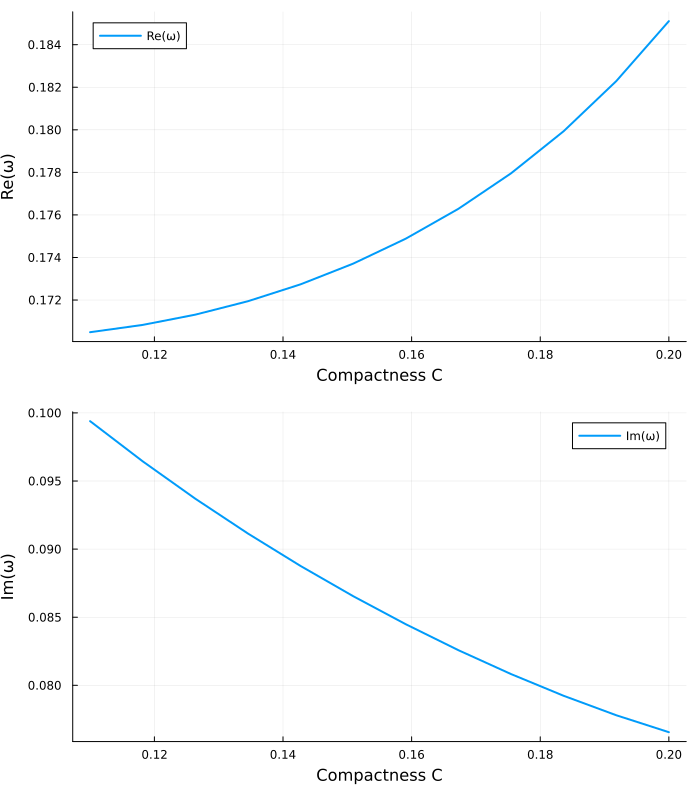

In [5]:
using Printf

function sweep_compactness(l::Int;
    C_values = range(0.10, 0.20, length=15),
    ω_init = 0.14 + 0.08im)

    ω_results = ComplexF64[]
    C_list = Float64[]

    ω_prev = ω_init

    for (i, C) in enumerate(C_values)

        println("\n==============================")
        println("Step $i: Compactness C = $C")

        # --- Find p0 ---
        p0 = OddParity.find_p0_for_compactness(C, 1e-6, 1e-4)
        println("p0 = $p0")

        # --- Define root function ---
        f_root = (w) -> QNMFinder.qnm_root_func(w, p0, l)

        # --- Build initial guesses around previous ω ---
        ω0 = ω_prev
        ω1 = ω_prev * (1.01 + 0.0im)
        ω2 = ω_prev * (0.99 + 0.01im)

        try
            ω_new, f_val, iters = QNMFinder.muller_method(
                f_root, ω0, ω1, ω2;
                max_iters=50, tol=1e-13
            )

            println("ω = $ω_new   |f| = $(abs(f_val))")

            push!(ω_results, ω_new)
            push!(C_list, C)

            # update continuation seed
            ω_prev = ω_new

        catch e
            println("⚠️ Failed at C = $C")
            println(e)
            break
        end
    end

    return C_list, ω_results
end


using Plots

function plot_qnm_branch(C_list, ω_results)

    ω_real = real.(ω_results)
    ω_imag = imag.(ω_results)

    p1 = plot(C_list, ω_real,
        xlabel="Compactness C",
        ylabel="Re(ω)",
        label="Re(ω)",
        lw=2)

    p2 = plot(C_list, ω_imag,
        xlabel="Compactness C",
        ylabel="Im(ω)",
        label="Im(ω)",
        lw=2)

    plot(p1, p2, layout=(2,1), size=(700,800))
end

l = 2

C_list, ω_results = sweep_compactness(l;
    C_values = range(0.11, 0.20, length=12),
    ω_init = 0.14 + 0.082im
)

plot_qnm_branch(C_list, ω_results)

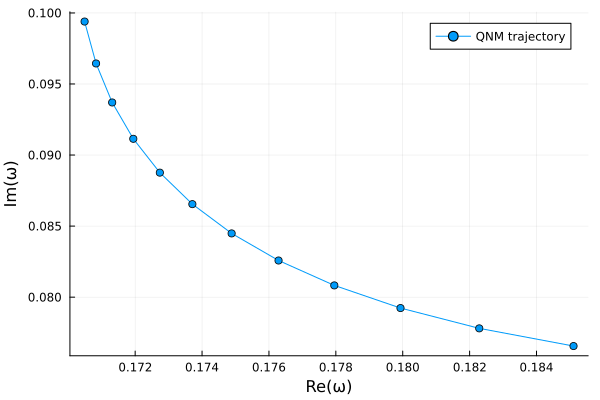

In [6]:

plot(real.(ω_results), imag.(ω_results),
    xlabel="Re(ω)",
    ylabel="Im(ω)",
    marker=:circle,
    label="QNM trajectory")

# Coarse grain scanning

In [34]:
Fmag(ω) = abs(QNMFinder.qnm_root_func(ω, p0, l))

function scan_qnm(p0, l;
    ωr_range = range(0.1, 0.8, length=80),
    ωi_range = range(0.02, 0.4, length=80))

    vals = zeros(length(ωr_range), length(ωi_range))

    for (i, ωr) in enumerate(ωr_range)
        for (j, ωi) in enumerate(ωi_range)
            ω = ωr + im*ωi
            vals[i,j] = abs(QNMFinder.qnm_root_func(ω, p0, l))
        end
    end

    return ωr_range, ωi_range, vals
end

function find_candidates(ωr_range, ωi_range, vals; threshold=0.05)

    candidates = ComplexF64[]

    for i in 2:length(ωr_range)-1
        for j in 2:length(ωi_range)-1

            v = vals[i,j]

            if v < threshold &&
               v < vals[i+1,j] && v < vals[i-1,j] &&
               v < vals[i,j+1] && v < vals[i,j-1]

                push!(candidates, ωr_range[i] + im*ωi_range[j])
            end
        end
    end

    return candidates
end

function refine_modes(candidates, p0, l)

    roots = ComplexF64[]

    f_root = (w) -> QNMFinder.qnm_root_func(w, p0, l)

    for ω0 in candidates
        ω1 = ω0 * (1.01 + 0im)
        ω2 = ω0 * (0.99 + 0.01im)

        try
            ω, _, _ = QNMFinder.muller_method(f_root, ω0, ω1, ω2)
            push!(roots, ω)
        catch
        end
    end

    return roots
end

p0 = OddParity.find_p0_for_compactness(0.14, 1e-6, 1e-4)
l = 2

ωr, ωi, vals = scan_qnm(p0, l)
candidates = find_candidates(ωr, ωi, vals)
roots = refine_modes(candidates, p0, l)

println("Modes found:")
for ω in roots
    println(ω)
end

In [18]:
# Fixed
Fmag(ω) = abs(QNMFinder.qnm_root_func(ω, p0, l))

function scan_qnm(p0, l;
    ωr_range = range(0.1, 0.8, length=200),
    ωi_range = range(0.02, 0.4, length=200))

    vals = zeros(length(ωr_range), length(ωi_range))

    for (i, ωr) in enumerate(ωr_range)
        for (j, ωi) in enumerate(ωi_range)
            ω = ωr + im*ωi
            vals[i,j] = abs(QNMFinder.qnm_root_func(ω, p0, l))
        end
    end

    return ωr_range, ωi_range, vals
end

function find_candidates(ωr_range, ωi_range, vals; n_candidates=20)

    candidates = ComplexF64[]

    inds = sortperm(vec(vals))

    for k in 1:n_candidates
        idx = inds[k]

        i, j = Tuple(CartesianIndices(vals)[idx])

        ω = ωr_range[i] + im*ωi_range[j]
        v = vals[i,j]

        println("Candidate $k → ω = $ω, |F| = $v")

        push!(candidates, ω)
    end

    return candidates
end

function refine_modes(candidates, p0, l)

    roots = ComplexF64[]
    f_root = (w) -> QNMFinder.qnm_root_func(w, p0, l)

    for ω0 in candidates

        δ = 0.002
        ω1 = ω0 + δ
        ω2 = ω0 + δ*im

        try
            ω, _, _ = QNMFinder.muller_method(f_root, ω0, ω1, ω2)
            push!(roots, ω)
        catch e
            println("Muller failed at ω0 = ", ω0)
        end
    end

    return roots
end

p0 = OddParity.find_p0_for_compactness(0.14, 1e-6, 1e-4)
l = 2

ωr, ωi, vals = scan_qnm(p0, l)
candidates = find_candidates(ωr, ωi, vals)
roots = refine_modes(candidates, p0, l)
println("Number of candidates: ", length(candidates))
println("Modes found:")
for ω in roots
    println(ω)
end

Candidate 1 → ω = 0.17386934673366833 + 0.08874371859296483im, |F| = 0.03654474045304267
Candidate 2 → ω = 0.17386934673366833 + 0.0906532663316583im, |F| = 0.040254544827758254
Candidate 3 → ω = 0.3603015075376884 + 0.06582914572864322im, |F| = 0.05090588352951899
Candidate 4 → ω = 0.17035175879396985 + 0.08874371859296483im, |F| = 0.052075956180241384
Candidate 5 → ω = 0.17035175879396985 + 0.0906532663316583im, |F| = 0.05470877503035501
Candidate 6 → ω = 0.17386934673366833 + 0.08683417085427135im, |F| = 0.06927407571938553
Candidate 7 → ω = 0.17386934673366833 + 0.09256281407035176im, |F| = 0.0739685915205079
Candidate 8 → ω = 0.3603015075376884 + 0.06391959798994974im, |F| = 0.07890507631606822
Candidate 9 → ω = 0.17035175879396985 + 0.08683417085427135im, |F| = 0.0799746618071165
Candidate 10 → ω = 0.17035175879396985 + 0.09256281407035176im, |F| = 0.08396336578730905
Candidate 11 → ω = 0.36381909547738694 + 0.06582914572864322im, |F| = 0.09660998395560001
Candidate 12 → ω = 0.36

In [ ]:
println("Minimum value of F = ", minimum(vals))


Minimum value of F = 0.03654474045304267


In [14]:
F_val = QNMFinder.qnm_root_func(0.17245427480294148 + 0.08953749697024348im, p0, l)
println("F(ω_test) = ", F_val)
println("|F| = ", abs(F_val))

F(ω_test) = 8.033006926311259e-9 + 4.311694112857367e-9im
|F| = 9.117011922829406e-9


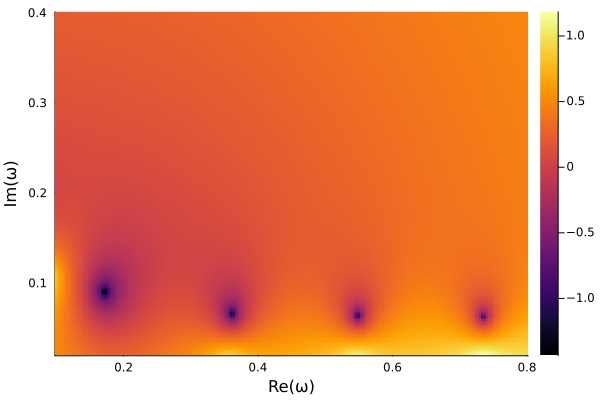

In [19]:
using Plots
heatmap(ωr, ωi, log10.(vals'),
    xlabel="Re(ω)", ylabel="Im(ω)")

# Tracking overtones

In [8]:
initial_modes = [
    0.14109853252101603 + 0.07801141148655444im,
    0.2892067494950219 + 0.08443022964589232im ,
    0.42839997917794154 + 0.09823964371478633im,
    0.5635663710575166 + 0.11350363994713941im,
    0.6928451896971852 + 0.13228853122052903im
]

5-element Vector{ComplexF64}:
 0.14109853252101603 + 0.07801141148655444im
  0.2892067494950219 + 0.08443022964589232im
 0.42839997917794154 + 0.09823964371478633im
  0.5635663710575166 + 0.11350363994713941im
  0.6928451896971852 + 0.13228853122052903im


C = 0.08
Muller Method starting...
  Base Guesses: ComplexF64[0.14109853252101603 + 0.07801141148655444im, 0.1425095178462262 + 0.07879152560141998im, 0.13890743308094033 + 0.07864228269689905im]
  f(Guesses):   ComplexF64[0.15127532335431831 + 0.1469907175281706im, 0.13181682611633572 + 0.15124089413616382im, 0.1653734071142044 + 0.12200604547829541im]
Iter 1: omega = 0.13523700963387025 + 0.1023480629347133im, |f(omega)| = 0.022207240526008552
Iter 2: omega = 0.13967964861459342 + 0.10390576489109901im, |f(omega)| = 0.004460932495685193
Iter 3: omega = 0.13939083626468873 + 0.10303005147569799im, |f(omega)| = 0.00013532288157906444
Iter 4: omega = 0.1394134457974398 + 0.10304441227294553im, |f(omega)| = 1.3424231733334802e-7
Iter 5: omega = 0.1394134689252646 + 0.10304439914362876im, |f(omega)| = 8.286929925083615e-13
Iter 6: omega = 0.13941346892532736 + 0.10304439914347706im, |f(omega)| = 1.4475537224895361e-15
Converged successfully.
mode 1: 0.13941346892532736 + 0.10304439914347

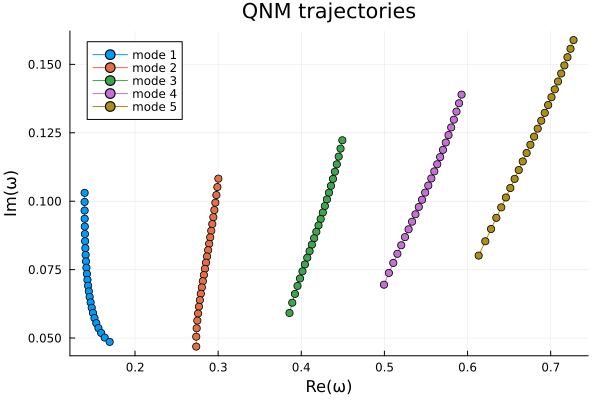

In [ ]:


function track_overtones(l::Int, initial_modes;
    C_values = range(0.11, 0.20, length=15))

    num_modes = length(initial_modes)

    # store results per mode
    ω_tracks = [ComplexF64[] for _ in 1:num_modes]

    # initialize seeds
    ω_prev = copy(initial_modes)

    for C in C_values

        println("\nC = $C")

        p0 = OddParity.find_p0_for_compactness(C, 1e-6, 1e-4)

        f_root = (w) -> QNMFinder.qnm_root_func(w, p0, l)

        for m in 1:num_modes
            ω0 = ω_prev[m]
            ω1 = ω0 * (1.01 + 0im)
            ω2 = ω0 * (0.99 + 0.01im)

            try
                ω_new, _, _ = QNMFinder.muller_method(f_root, ω0, ω1, ω2)

                push!(ω_tracks[m], ω_new)
                ω_prev[m] = ω_new

                println("mode $m: $ω_new")

            catch
                println("mode $m failed at C = $C")
                push!(ω_tracks[m], NaN + NaN*im)
            end
        end
    end

    return C_values, ω_tracks
end

using Plots

function plot_overtones(C_values, ω_tracks)

    p1 = plot(title="Re(ω) vs C", xlabel="C", ylabel="Re(ω)")
    p2 = plot(title="Im(ω) vs C", xlabel="C", ylabel="Im(ω)")

    for (i, ωs) in enumerate(ω_tracks)
        plot!(p1, C_values, real.(ωs), label="mode $i")
        plot!(p2, C_values, imag.(ωs), label="mode $i")
    end

    plot(p1, p2, layout=(2,1), size=(700,800))
end

function plot_trajectories(ω_tracks)

    p = plot(xlabel="Re(ω)", ylabel="Im(ω)", title="QNM trajectories")

    for (i, ωs) in enumerate(ω_tracks)
        plot!(p, real.(ωs), imag.(ωs),
              marker=:circle, label="mode $i")
    end

    return p
end

l = 2

C_vals, ω_tracks = track_overtones(l, initial_modes;
    C_values = range(0.08, 0.24, length=25))

plot_overtones(C_vals, ω_tracks)
plot_trajectories(ω_tracks)

Muller Method starting...
  Base Guesses: ComplexF64[0.14109853252101603 + 0.07801141148655444im, 0.1425095178462262 + 0.07879152560141998im, 0.13890743308094033 + 0.07864228269689905im]
  f(Guesses):   ComplexF64[0.07698247006298525 + 0.08058031356992212im, 0.05897729790806061 + 0.08563030734175747im, 0.08873764971843318 + 0.05621510704100152im]
Iter 1: omega = 0.13939293156966923 + 0.08942776821833912im, |f(omega)| = 0.0023966509623621385
Iter 2: omega = 0.13969760454978172 + 0.0893734151449793im, |f(omega)| = 6.412849798838669e-5
Iter 3: omega = 0.13969271837971722 + 0.08936683398007522im, |f(omega)| = 4.7962928693319656e-8
Iter 4: omega = 0.13969272450140655 + 0.08936683372783064im, |f(omega)| = 2.687840541703912e-14
Converged successfully.
Muller Method starting...
  Base Guesses: ComplexF64[0.2892067494950219 + 0.08443022964589232im, 0.29209881698997214 + 0.08527453194235124im, 0.2854703797036127 + 0.08647799484438362im]
  f(Guesses):   ComplexF64[0.0992275537463296 + 0.033373384

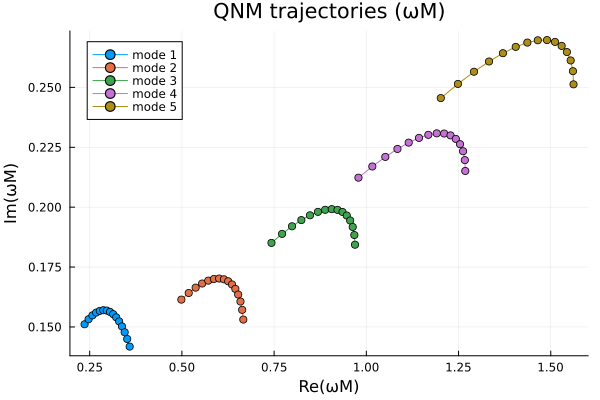

In [18]:
function track_overtones(l::Int, initial_modes;
    C_values = range(0.11, 0.20, length=15))

    num_modes = length(initial_modes)

    ω_tracks = [ComplexF64[] for _ in 1:num_modes]
    M_list = Float64[]   # <-- NEW

    ω_prev = copy(initial_modes)

    for C in C_values

        p0 = OddParity.find_p0_for_compactness(C, 1e-6, 1e-4)

        # get M from background
        res = OddParity.solve_odd(p0, l, ω_prev[1])
        M = res.tov.M_tov
        push!(M_list, M)

        f_root = (w) -> QNMFinder.qnm_root_func(w, p0, l)

        for m in 1:num_modes
            ω0 = ω_prev[m]
            ω1 = ω0 * (1.01 + 0im)
            ω2 = ω0 * (0.99 + 0.01im)

            try
                ω_new, _, _ = QNMFinder.muller_method(f_root, ω0, ω1, ω2)
                push!(ω_tracks[m], ω_new)
                ω_prev[m] = ω_new
            catch
                push!(ω_tracks[m], NaN + NaN*im)
            end
        end
    end

    return C_values, ω_tracks, M_list
end

function plot_overtones_M(C_values, ω_tracks, M_list)


    p1 = plot(title="Re(ωM) vs C", xlabel="C", ylabel="Re(ωM)")
    p2 = plot(title="Im(ωM) vs C", xlabel="C", ylabel="Im(ωM)")

    for (i, ωs) in enumerate(ω_tracks)

        ωM = [ωs[j] * M_list[j] for j in eachindex(C_values)]

        plot!(p1, C_values, real.(ωM), label="mode $i")
        plot!(p2, C_values, imag.(ωM), label="mode $i")
    end

    plot(p1, p2, layout=(2,1), size=(700,800))
end

function plot_trajectories_M(ω_tracks, M_list)



    p = plot(xlabel="Re(ωM)", ylabel="Im(ωM)", title="QNM trajectories (ωM)")

    for (i, ωs) in enumerate(ω_tracks)

        ωM = [ωs[j] * M_list[j] for j in eachindex(ωs)]

        plot!(p, real.(ωM), imag.(ωM),
              marker=:circle, label="mode $i")
    end

    return p
end

C_vals, ω_tracks, M_list = track_overtones(l, initial_modes)

plot_overtones_M(C_vals, ω_tracks, M_list)
plot_trajectories_M(ω_tracks, M_list)

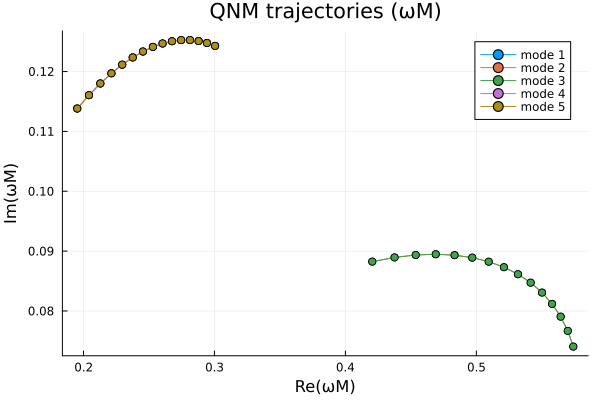

In [33]:
function track_overtones(l::Int, initial_modes;
    C_values = range(0.11, 0.20, length=15))

    num_modes = length(initial_modes)

    ω_tracks = [ComplexF64[] for _ in 1:num_modes]
    M_list = Float64[]   # <-- NEW

    ω_prev = copy(initial_modes)

    for C in C_values

        p0 = OddParity.find_p0_for_compactness(C, 1e-6, 1e-4)

        # get M from background
        res = OddParity.solve_odd(p0, l, ω_prev[1])
        M = res.tov.M_tov
        push!(M_list, M)

        f_root = (w) -> QNMFinder.qnm_root_func(w, p0, l)

        for m in 1:num_modes
            ω0 = ω_prev[m]
            ω1 = ω0 * (1.01 + 0im)
            ω2 = ω0 * (0.99 + 0.01im)

            try
                ω_new, _, _ = QNMFinder.muller_method(f_root, ω0, ω1, ω2)
                push!(ω_tracks[m], ω_new)
                ω_prev[m] = ω_new
            catch
                push!(ω_tracks[m], NaN + NaN*im)
            end
        end
    end

    return C_values, ω_tracks, M_list
end

function plot_overtones_M(C_values, ω_tracks, M_list)


    p1 = plot(title="Re(ωM) vs C", xlabel="C", ylabel="Re(ωM)")
    p2 = plot(title="Im(ωM) vs C", xlabel="C", ylabel="Im(ωM)")

    for (i, ωs) in enumerate(ω_tracks)

        ωM = [ωs[j] * M_list[j] for j in eachindex(C_values)]

        plot!(p1, C_values, real.(ωM), label="mode $i")
        plot!(p2, C_values, imag.(ωM), label="mode $i")
    end

    plot(p1, p2, layout=(2,1), size=(700,800))
end

function plot_trajectories_M(ω_tracks, M_list)



    p = plot(xlabel="Re(ωM)", ylabel="Im(ωM)", title="QNM trajectories (ωM)")

    for (i, ωs) in enumerate(ω_tracks)

        ωM = [ωs[j] * M_list[j] for j in eachindex(ωs)]

        plot!(p, real.(ωM), imag.(ωM),
              marker=:circle, label="mode $i")
    end

    return p
end

C_vals, ω_tracks, M_list = track_overtones(l, initial_modes)

plot_overtones_M(C_vals, ω_tracks, M_list)
plot_trajectories_M(ω_tracks, M_list)

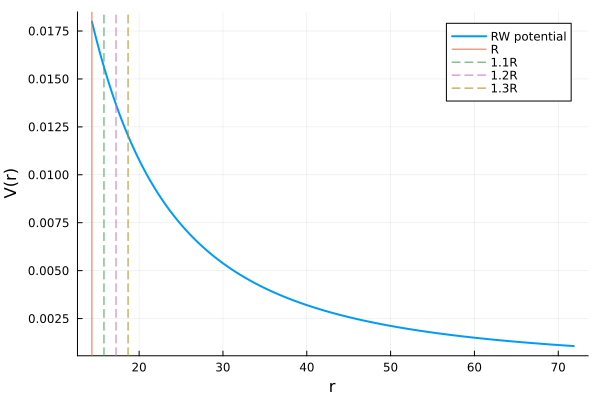

In [10]:
using Plots

function rw_potential(r, l, M)
    f = 1.0 - 2.0*M/r
    return f * (l*(l+1)/r^2 - 6.0*M/r^3)
end

function plot_rw_potential(p0, l;
    r_factor_max = 5.0)

    # Get background
    res = OddParity.solve_odd(p0, l, 0.0)  # ω irrelevant here
    R = res.tov.R_tov
    M = res.tov.M_tov

    # radial grid
    r_vals = range(R, r_factor_max*R, length=500)
    V_vals = [rw_potential(r, l, M) for r in r_vals]

    # plot
    p = plot(r_vals, V_vals,
        xlabel="r",
        ylabel="V(r)",
        label="RW potential",
        lw=2)

    # mark R
    vline!(p, [R], label="R")

    # mark a few candidate R2 values
    vline!(p, [1.1R], linestyle=:dash, label="1.1R")
    vline!(p, [1.2R], linestyle=:dash, label="1.2R")
    vline!(p, [1.3R], linestyle=:dash, label="1.3R")

    return p
end

l = 2
C = 0.14

p0 = OddParity.find_p0_for_compactness(C, 1e-6, 1e-4)

plot_rw_potential(p0, l)

In [14]:
l = 2
C = 0.14
R2f = 1.1

p0 = OddParity.find_p0_for_compactness(C, 1e-6, 1e-4)

f = (w) -> QNMFinder.qnm_root_func(w, p0, l; R2_factor=R2f)

QNMFinder.muller_method(f,
    0.14 + 0.08im,
    0.141 + 0.08im,
    0.139 + 0.081im
)

Muller Method starting...
  Base Guesses: ComplexF64[0.14 + 0.08im, 0.141 + 0.08im, 0.139 + 0.081im]
  f(Guesses):   ComplexF64[0.07589904433063399 - 0.2584388905373525im, 0.07351630789471708 - 0.240779920136027im, 0.05957658314968728 - 0.27810039016658283im]
Iter 1: omega = 0.15726640150349325 + 0.07705486577464583im, |f(omega)| = 0.016106689853855317
Iter 2: omega = 0.15810144712991242 + 0.0779018719926662im, |f(omega)| = 0.0009633580241568637
Iter 3: omega = 0.15808030558826988 + 0.07797395786679846im, |f(omega)| = 3.6489869535279193e-6
Iter 4: omega = 0.1580800859871475 + 0.07797377710427052im, |f(omega)| = 4.550933360484013e-11
Converged successfully.


(0.1580800859871475 + 0.07797377710427052im, 3.742800513961697e-11 + 2.58890686666291e-11im, 4)


Running sweep for R2 = 1.1 * R

[C=0.11 | R2f=1.1]
At R2 = 16.909695291760983: Z'/Z = 0.14207547963352843 - 0.10128120966358196im, chi_ratio = 0.10249999973983277 - 0.17499999955581208im, k = 0.039575479893695656 + 0.07371878989223012im
At R2 = 16.909695291760983: Z'/Z = 0.14187531084796962 - 0.10348585010415284im, chi_ratio = 0.10352499973723112 - 0.17674999955137022im, k = 0.0383503111107385 + 0.07326414944721737im
At R2 = 16.909695291760983: Z'/Z = 0.14445635039512897 - 0.09931545224106439im, chi_ratio = 0.10322499973799257 - 0.1722249995628556im, k = 0.0412313506571364 + 0.07290954732179122im
Muller Method starting...
  Base Guesses: ComplexF64[0.14 + 0.082im, 0.14140000000000003 + 0.08282im, 0.13778 + 0.08258im]
  f(Guesses):   ComplexF64[0.2174947688869715 + 0.010305722307063947im, 0.19976892840170768 + 0.023385807130947622im, 0.22062440887341744 - 0.02170443139583611im]
At R2 = 16.909695291760983: Z'/Z = 0.16878785612205777 - 0.12105074252065776im, chi_ratio = 0.133470338017015

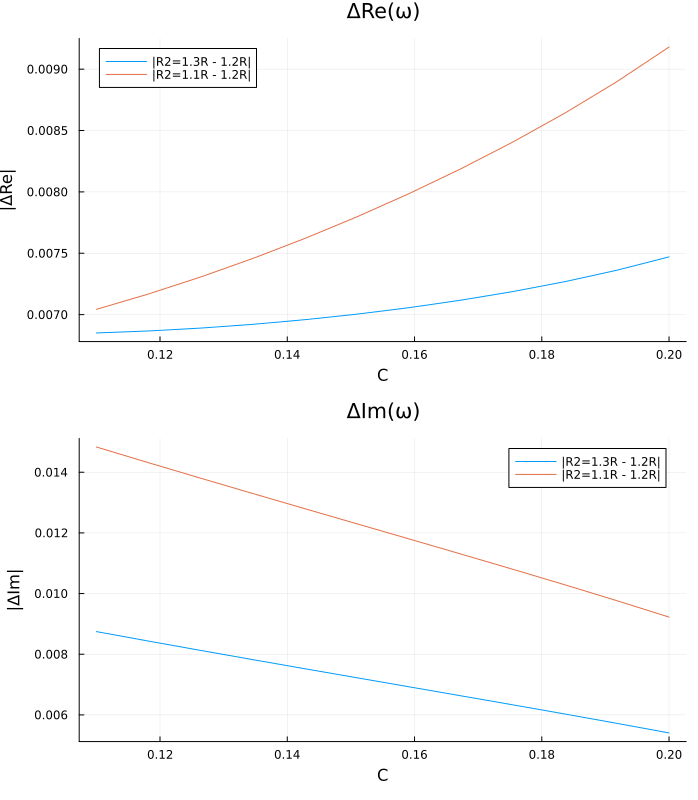

In [38]:
function sweep_C_and_R2(l::Int;
    C_values = range(0.11, 0.20, length=12),
    R2_factors = [1.01, 1.02, 1.03],
    ω_init = 0.14 + 0.08im
)

    results = Dict{Float64, Vector{ComplexF64}}()

    for R2f in R2_factors
        results[R2f] = ComplexF64[]
    end

    for R2f in R2_factors

        println("\n==============================")
        println("Running sweep for R2 = $(R2f) * R")

        ω_prev = ω_init

        for (i, C) in enumerate(C_values)

            println("\n[C=$C | R2f=$R2f]")

            p0 = OddParity.find_p0_for_compactness(C, 1e-6, 1e-4)

            f_root = (w) -> QNMFinder.qnm_root_func(w, p0, l; R2_factor=R2f)

            ω0 = ω_prev
            ω1 = ω_prev * (1.01 + 0im)
            ω2 = ω_prev * (0.99 + 0.01im)

            try
                ω_new, f_val, _ = QNMFinder.muller_method(
                    f_root, ω0, ω1, ω2;
                    max_iters=50, tol=1e-13
                )

                push!(results[R2f], ω_new)
                ω_prev = ω_new

                println("ω = $ω_new |f|=$(abs(f_val))")

            catch e
                println("FAILED at C=$C, R2f=$R2f")
                println(e)
                rethrow(e)   # 🔥 temporarily crash to see real issue
            end
        
        end
    end

    return C_values, results
end

function plot_R2_comparison(C_values, results)

    p1 = plot(title="Re(ω) vs C", xlabel="C", ylabel="Re(ω)")
    p2 = plot(title="Im(ω) vs C", xlabel="C", ylabel="Im(ω)")

    for (R2f, ωs) in results
        plot!(p1, C_values, real.(ωs), label="R2=$(R2f)R")
        plot!(p2, C_values, imag.(ωs), label="R2=$(R2f)R")
    end

    plot(p1, p2, layout=(2,1), size=(700,800))
end

function plot_R2_differences(C_values, results; ref=1.2)

    ref_vals = results[ref]

    p1 = plot(title="ΔRe(ω)", xlabel="C", ylabel="|ΔRe|")
    p2 = plot(title="ΔIm(ω)", xlabel="C", ylabel="|ΔIm|")

    for (R2f, ωs) in results
        if R2f == ref
            continue
        end

        ΔRe = abs.(real.(ωs) .- real.(ref_vals))
        ΔIm = abs.(imag.(ωs) .- imag.(ref_vals))

        plot!(p1, C_values, ΔRe, label="|R2=$(R2f)R - $(ref)R|")
        plot!(p2, C_values, ΔIm, label="|R2=$(R2f)R - $(ref)R|")
    end

    plot(p1, p2, layout=(2,1), size=(700,800))
end

l = 2

C_vals, results = sweep_C_and_R2(l;
    C_values = range(0.11, 0.20, length=12),
    R2_factors = [1.1, 1.2, 1.3],
    ω_init = 0.14 + 0.082im
)

plot_R2_comparison(C_vals, results)
plot_R2_differences(C_vals, results)

In [20]:
initial_modes = [
    0.14109853252101603 + 0.07801141148655444im,
    0.2892067494950219 + 0.08443022964589232im,
    0.42839997917794154 + 0.09823964371478633im,
    0.5635663710575166 + 0.11350363994713941im,
    0.6928451896971852 + 0.13228853122052903im
]

5-element Vector{ComplexF64}:
 0.14109853252101603 + 0.07801141148655444im
  0.2892067494950219 + 0.08443022964589232im
 0.42839997917794154 + 0.09823964371478633im
  0.5635663710575166 + 0.11350363994713941im
  0.6928451896971852 + 0.13228853122052903im

In [12]:
"""function track_overtones(l::Int, initial_modes;
    C_values = range(0.11, 0.20, length=30))

    num_modes = length(initial_modes)

    ω_tracks = [ComplexF64[] for _ in 1:num_modes]
    M_list = Float64[]

    ω_prev = copy(initial_modes)

    for C in C_values

        println("\n--- C = $C ---")

        p0 = OddParity.find_p0_for_compactness(C, 1e-6, 1e-4)

        # background mass
        res = OddParity.solve_odd(p0, l, ω_prev[1])
        M = res.tov.M_tov
        push!(M_list, M)

        f_root = (w) -> QNMFinder.qnm_root_func(w, p0, l)

        for m in 1:num_modes

            ω0 = ω_prev[m]

            # 🔥 smaller, safer perturbations
            δ = 0.003
            guesses = [
                (ω0, ω0*(1+δ), ω0*(1-δ+0.002im)),
                (ω0, ω0*(1+2δ), ω0*(1-2δ+0.003im))
            ]

            ω_candidates = ComplexF64[]

            for (g0, g1, g2) in guesses
                try
                    ω_new, _, _ = QNMFinder.muller_method(f_root, g0, g1, g2)
                    push!(ω_candidates, ω_new)
                catch
                    # ignore failed attempt
                end
            end

            if !isempty(ω_candidates)
                # 🔥 pick root closest to previous value
                #idx = argmin(abs.(ω_candidates .- ω_prev[m]))
                # penalize jumping near neighboring modes
                distances = abs.(ω_candidates .- ω_prev[m])

                if m > 1
                    distances .+= 0.5 ./ abs.(ω_candidates .- ω_prev[m-1])
                end
                if m < num_modes
                    distances .+= 0.5 ./ abs.(ω_candidates .- ω_prev[m+1])
                end

                idx = argmin(distances)
                ω_new = ω_candidates[idx]

                push!(ω_tracks[m], ω_new)
                ω_prev[m] = ω_new

                println("Mode $m → ω = $ω_new")

            else
                println("Mode $m FAILED")

                # ❗ DO NOT DROP MODE — keep continuity
                push!(ω_tracks[m], ω_prev[m])
            end
        end
    end

    return C_values, ω_tracks, M_list
end"""

function track_overtones(l::Int, initial_modes;
    C_values = range(0.11, 0.24, length=30))

    num_modes = length(initial_modes)

    ω_tracks = [ComplexF64[] for _ in 1:num_modes]
    M_list = Float64[]

    # --- compute M_list once ---
    for i in eachindex(C_values)
        Ci = C_values[i]

        p0 = OddParity.find_p0_for_compactness(Ci, 1e-6, 1e-4)
        res = OddParity.solve_odd(p0, l, initial_modes[1])
        push!(M_list, res.tov.M_tov)
    end

    # --- track each mode separately ---
    for m in 1:num_modes

        println("\nTracking mode $m")

        ω_prev = initial_modes[m]

        for j in eachindex(C_values)
            Ci = C_values[j]
                             

            p0 = OddParity.find_p0_for_compactness(Ci, 1e-6, 1e-4)
            f_root = (w) -> QNMFinder.qnm_root_func(w, p0, l)

            δ = 0.002

            ω0 = ω_prev
            ω1 = ω0 * (1 + δ)
            ω2 = ω0 * (1 - δ + 0.002im)

            try
                ω_new, _, _ = QNMFinder.muller_method(f_root, ω0, ω1, ω2)

                push!(ω_tracks[m], ω_new)
                ω_prev = ω_new

                println("Ci=$Ci → ω = $ω_new")

            catch
                println("Mode $m FAILED at Ci=$Ci")

                # keep previous value instead of losing mode
                push!(ω_tracks[m], ω_prev)
            end
        end
    end

    return C_values, ω_tracks, M_list
end

function plot_trajectories_M(ω_tracks, M_list)

    p = plot(xlabel="Re(ωM)", ylabel="Im(ωM)",
             title="QNM trajectories (ωM)")

    for (i, ωs) in enumerate(ω_tracks)

        ωM = ComplexF64[]

        for j in eachindex(ωs)
            if !isnan(real(ωs[j]))
                push!(ωM, ωs[j] * M_list[j])
            end
        end

        if !isempty(ωM)
            plot!(p, real.(ωM), imag.(ωM),
                  marker=:circle, label="mode $i")
        else
            println("Mode $i completely missing!")
        end
    end

    return p
end

C_vals, ω_tracks, M_list = track_overtones(l, initial_modes)

plot_overtones_M(C_vals, ω_tracks, M_list)
plot_trajectories_M(ω_tracks, M_list)

UndefVarError: UndefVarError: `C` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [22]:
for j in eachindex(1:5)
    C = j
    println(C)
end

1
2
3
4
5


In [18]:
function plot_trajectories_M(ω_tracks, M_list)

    p = plot(xlabel="Re(ωM)", ylabel="Im(ωM)",
             title="QNM trajectories (ωM)")

    for (i, ωs) in enumerate(ω_tracks)

        ωM = ComplexF64[]

        for j in eachindex(ωs)
            if !isnan(real(ωs[j]))
                push!(ωM, ωs[j] * M_list[j])
            end
        end

        if !isempty(ωM)
            plot!(p, real.(ωM), imag.(ωM),
                  marker=:circle, label="mode $i")
        else
            println("Mode $i completely missing!")
        end
    end

    return p
end

function plot_overtones_M(C_values, ω_tracks, M_list)


    p1 = plot(title="Re(ωM) vs C", xlabel="C", ylabel="Re(ωM)")
    p2 = plot(title="Im(ωM) vs C", xlabel="C", ylabel="Im(ωM)")

    for (i, ωs) in enumerate(ω_tracks)

        ωM = [ωs[j] * M_list[j] for j in eachindex(C_values)]

        plot!(p1, C_values, real.(ωM), label="mode $i")
        plot!(p2, C_values, imag.(ωM), label="mode $i")
    end

    plot(p1, p2, layout=(2,1), size=(700,800))
end

function track_overtones(l::Int, initial_modes;
    C_values = range(0.11, 0.24, length=30))

    num_modes = length(initial_modes)

    ω_tracks = [ComplexF64[] for _ in 1:num_modes]
    M_list = Float64[]

    for i in eachindex(C_values)
        C = C_values[i]

        p0 = OddParity.find_p0_for_compactness(C, 1e-6, 1e-4)
        res = OddParity.solve_odd(p0, l, initial_modes[1])
        push!(M_list, res.tov.M_tov)
    end

    for m in 1:num_modes

        println("\nTracking mode $m")

        ω_prev = initial_modes[m]

        for j in eachindex(C_values)

            C = C_values[j]

            p0 = OddParity.find_p0_for_compactness(C, 1e-6, 1e-4)
            f_root = (w) -> QNMFinder.qnm_root_func(w, p0, l)

            δ = 0.002

            ω0 = ω_prev
            ω1 = ω0 * (1 + δ)
            ω2 = ω0 * (1 - δ + 0.002im)

            try
                ω_new, _, _ = QNMFinder.muller_method(f_root, ω0, ω1, ω2)

                push!(ω_tracks[m], ω_new)
                ω_prev = ω_new

                println("C=$(C) → ω = $(ω_new)")

            catch
                println("Mode $m FAILED at C=$(C)")
                push!(ω_tracks[m], ω_prev)
            end
        end
    end

    return C_values, ω_tracks, M_list
end

track_overtones (generic function with 1 method)


Tracking mode 1
Muller Method starting...
  Base Guesses: ComplexF64[0.14109853252101603 + 0.07801141148655444im, 0.14138072958605807 + 0.07816743430952755im, 0.14066031263300088 + 0.07813758572862335im]
  f(Guesses):   ComplexF64[0.6947190201607084 - 0.7092841688233689im, 0.6863587595861789 - 0.7006644980697077im, 0.6944627095352783 - 0.7263892912158445im]
Iter 1: omega = 0.16368387858321673 + 0.10200664337950584im, |f(omega)| = 0.14374083983550687
Iter 2: omega = 0.17129602984932302 + 0.10089216562770252im, |f(omega)| = 0.03182783303753669
Iter 3: omega = 0.17045624499283926 + 0.09935382966211508im, |f(omega)| = 0.0009756255822486229
Iter 4: omega = 0.1704880908762275 + 0.0993940684804899im, |f(omega)| = 9.657126491018385e-7
Iter 5: omega = 0.17048812513575004 + 0.09939410608302693im, |f(omega)| = 6.206360282141034e-12
Iter 6: omega = 0.17048812513559902 + 0.09939410608331688im, |f(omega)| = 5.613217783960923e-15
Converged successfully.
C=0.11 → ω = 0.17048812513559902 + 0.099394106

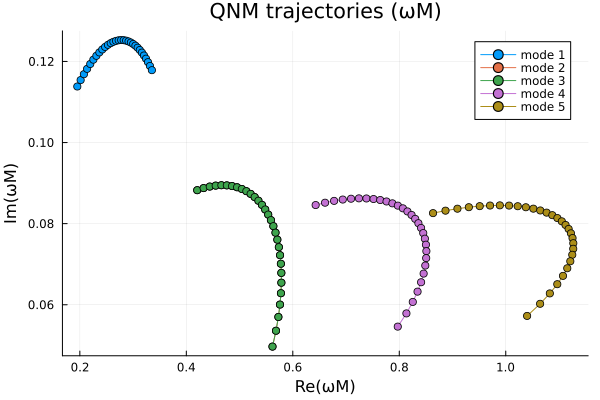

In [19]:
C_vals, ω_tracks, M_list = track_overtones(l, initial_modes)

plot_overtones_M(C_vals, ω_tracks, M_list)
plot_trajectories_M(ω_tracks, M_list)

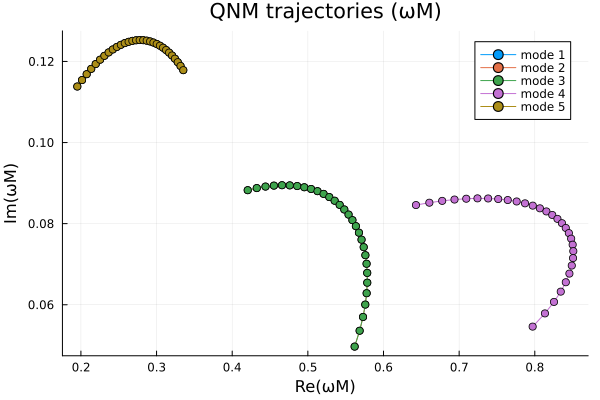

In [32]:
C_vals, ω_tracks, M_list = track_overtones(l, initial_modes)

plot_overtones_M(C_vals, ω_tracks, M_list)
plot_trajectories_M(ω_tracks, M_list)